# HATR su dataset interi: River vs CapyMOA

## Setup

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(
    os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), (
    f'JAR non trovato: {HATR_JAR}\n'
    'compilare: cd implementation/hatr-moa && mvn package -DskipTests')

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel → Restart & Run All')
else:
    os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print('Setup OK')

Setup OK


## Datasets

In [2]:
HYPER_N  = 50_000

import urllib.request, gzip, shutil

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), 'data'))
os.makedirs(DATA_DIR, exist_ok=True)

_ELEC_PATH = os.path.join(DATA_DIR, 'electricity.arff')
_ELEC_URL  = 'https://www.dropbox.com/scl/fi/p7btran9xdas20neva917/electricity.arff.gz?rlkey=xt8hc6542b8wr01eitcw7mwpz&st=paqojdax&dl=1'
if not os.path.exists(_ELEC_PATH):
    print('Downloading electricity.arff...')
    _gz = _ELEC_PATH + '.gz'
    urllib.request.urlretrieve(_ELEC_URL, _gz)
    with gzip.open(_gz, 'rb') as _f_in, open(_ELEC_PATH, 'wb') as _f_out:
        shutil.copyfileobj(_f_in, _f_out)
    os.remove(_gz)
    print('Done.')

datasets = {}
datasets['Bike']             = utils.materialize_stream(Bike())
datasets['Fried']            = utils.materialize_stream(Fried())
datasets['Hyper']            = utils.materialize_stream(
    HyperPlaneRegression(
        instance_random_seed=1, number_of_attributes=10,
        number_of_drifting_attributes=2, magnitude_of_change=0.001,
        noise_percentage=5),
    max_instances=HYPER_N)
datasets['HyperFast']        = utils.materialize_stream(
    HyperPlaneRegression(
        instance_random_seed=1, number_of_attributes=10,
        number_of_drifting_attributes=5, magnitude_of_change=0.1,
        noise_percentage=10),
    max_instances=HYPER_N)
datasets['FriedDrift']       = utils.make_fried_drift()
datasets['RBFReg']           = utils.make_rbf_regression()
datasets['ElectricityDemand'] = utils.load_electricity_demand(
    os.path.join(DATA_DIR, 'electricity.arff'))

for name, (X, y, _) in datasets.items():
    print(f'{name:<20}  n={len(X):>6}  feat={X.shape[1]:>2}  '
          f'y∈[{y.min():.2f}, {y.max():.2f}]')

Bike                  n= 17379  feat=12  y∈[1.00, 977.00]
Fried                 n= 40768  feat=10  y∈[-1.23, 30.52]
Hyper                 n= 50000  feat=10  y∈[56.28, 677.42]
HyperFast             n= 50000  feat=10  y∈[-16481.32, 71348.53]
FriedDrift            n= 40000  feat=10  y∈[-1.45, 29.77]
RBFReg                n= 30000  feat=10  y∈[-15.46, 16.23]
ElectricityDemand     n= 45312  feat= 7  y∈[0.00, 1.00]


## Parametri

In [3]:
BASE = dict(
    grace_period            = 200,
    delta                   = 1e-7,
    tau                     = 0.05,
    leaf_prediction         = 'adaptive',
    bootstrap_sampling      = False,
    model_selector_decay    = 0.95,
    drift_window_threshold  = 500,
    switch_significance     = 0.05,
    min_samples_split       = 5,
    adwin_delta             = 0.0001,
    learning_ratio          = 0.01,
    seed                    = 0,
)

CFG   = {'leaf_prediction': BASE['leaf_prediction'], 'bootstrap_sampling': BASE['bootstrap_sampling']}
SCALE = True
SKIP  = 50

print('Parametri configurati:', BASE)

Parametri configurati: {'grace_period': 200, 'delta': 1e-07, 'tau': 0.05, 'leaf_prediction': 'adaptive', 'bootstrap_sampling': False, 'model_selector_decay': 0.95, 'drift_window_threshold': 500, 'switch_significance': 0.05, 'min_samples_split': 5, 'adwin_delta': 0.0001, 'learning_ratio': 0.01, 'seed': 0}


## Esecuzione

In [4]:
# warmup JVM: evita che il JIT di HotSpot penalizzi il primo dataset (Bike)
_w_X, _w_y, _w_schema = next(iter(datasets.values()))
utils.prequential_eval(_w_X[:10000], _w_y[:10000], 'capy', CFG, BASE, schema=_w_schema, scale=SCALE)

results = {}

for name, (X, y, schema) in datasets.items():
    print(f'{name} — River ...', end=' ', flush=True)
    rp, _, t_p_r, t_t_r, _ = utils.prequential_eval(X, y, 'river', CFG, BASE, scale=SCALE, time_algo=True)
    print(f'{t_p_r + t_t_r:.1f}s | CapyMOA ...', end=' ', flush=True)
    cp, _, t_p_c, t_t_c, _ = utils.prequential_eval(X, y, 'capy', CFG, BASE, schema=schema, scale=SCALE, time_algo=True)
    print(f'{t_p_c + t_t_c:.1f}s')
    results[name] = {'y': y, 'river': rp, 'capy': cp}

print('\nDone.')

Bike — River ... 1.0s | CapyMOA ... 0.6s
Fried — River ... 3.3s | CapyMOA ... 1.1s
Hyper — River ... 3.9s | CapyMOA ... 1.3s
HyperFast — River ... 3.7s | CapyMOA ... 1.5s
FriedDrift — River ... 4.2s | CapyMOA ... 1.2s
RBFReg — River ... 2.7s | CapyMOA ... 0.7s
ElectricityDemand — River ... 2.2s | CapyMOA ... 0.8s

Done.


## Risultati

In [5]:
rows = []
for name, d in results.items():
    yt, rp, cp = d['y'], d['river'], d['capy']
    for fwk, yp in [('River', rp), ('CapyMOA', cp)]:
        rows.append(dict(
            Dataset   = name,
            Framework = fwk,
            N         = len(yt),
            MAE       = utils.mae(yt[SKIP:], yp[SKIP:]),
            RMSE      = utils.rmse(yt[SKIP:], yp[SKIP:]),
            R2        = utils.r2(yt[SKIP:], yp[SKIP:]),
        ))

df = pd.DataFrame(rows).set_index(['Dataset', 'Framework'])
df['MAE']  = df['MAE'].map('{:.4f}'.format)
df['RMSE'] = df['RMSE'].map('{:.4f}'.format)
df['R2']   = df['R2'].map('{:.4f}'.format)
print(df.to_string())

                                 N       MAE      RMSE       R2
Dataset           Framework                                    
Bike              River      17379   69.7574  116.8198   0.5855
                  CapyMOA    17379   69.7574  116.8198   0.5855
Fried             River      40768    1.6362    2.1096   0.8218
                  CapyMOA    40768    1.6362    2.1096   0.8218
Hyper             River      50000    7.9098   14.8632   0.9535
                  CapyMOA    50000    7.9098   14.8632   0.9535
HyperFast         River      50000  286.9853  587.8745   0.9656
                  CapyMOA    50000  286.9853  587.8745   0.9656
FriedDrift        River      40000    1.9312    2.5043   0.7487
                  CapyMOA    40000    1.9312    2.5043   0.7487
RBFReg            River      30000    1.9207    2.5271   0.3096
                  CapyMOA    30000    1.9207    2.5271   0.3096
ElectricityDemand River      45312    0.0517    0.1949  -0.4233
                  CapyMOA    45312    0.

## Curve di apprendimento

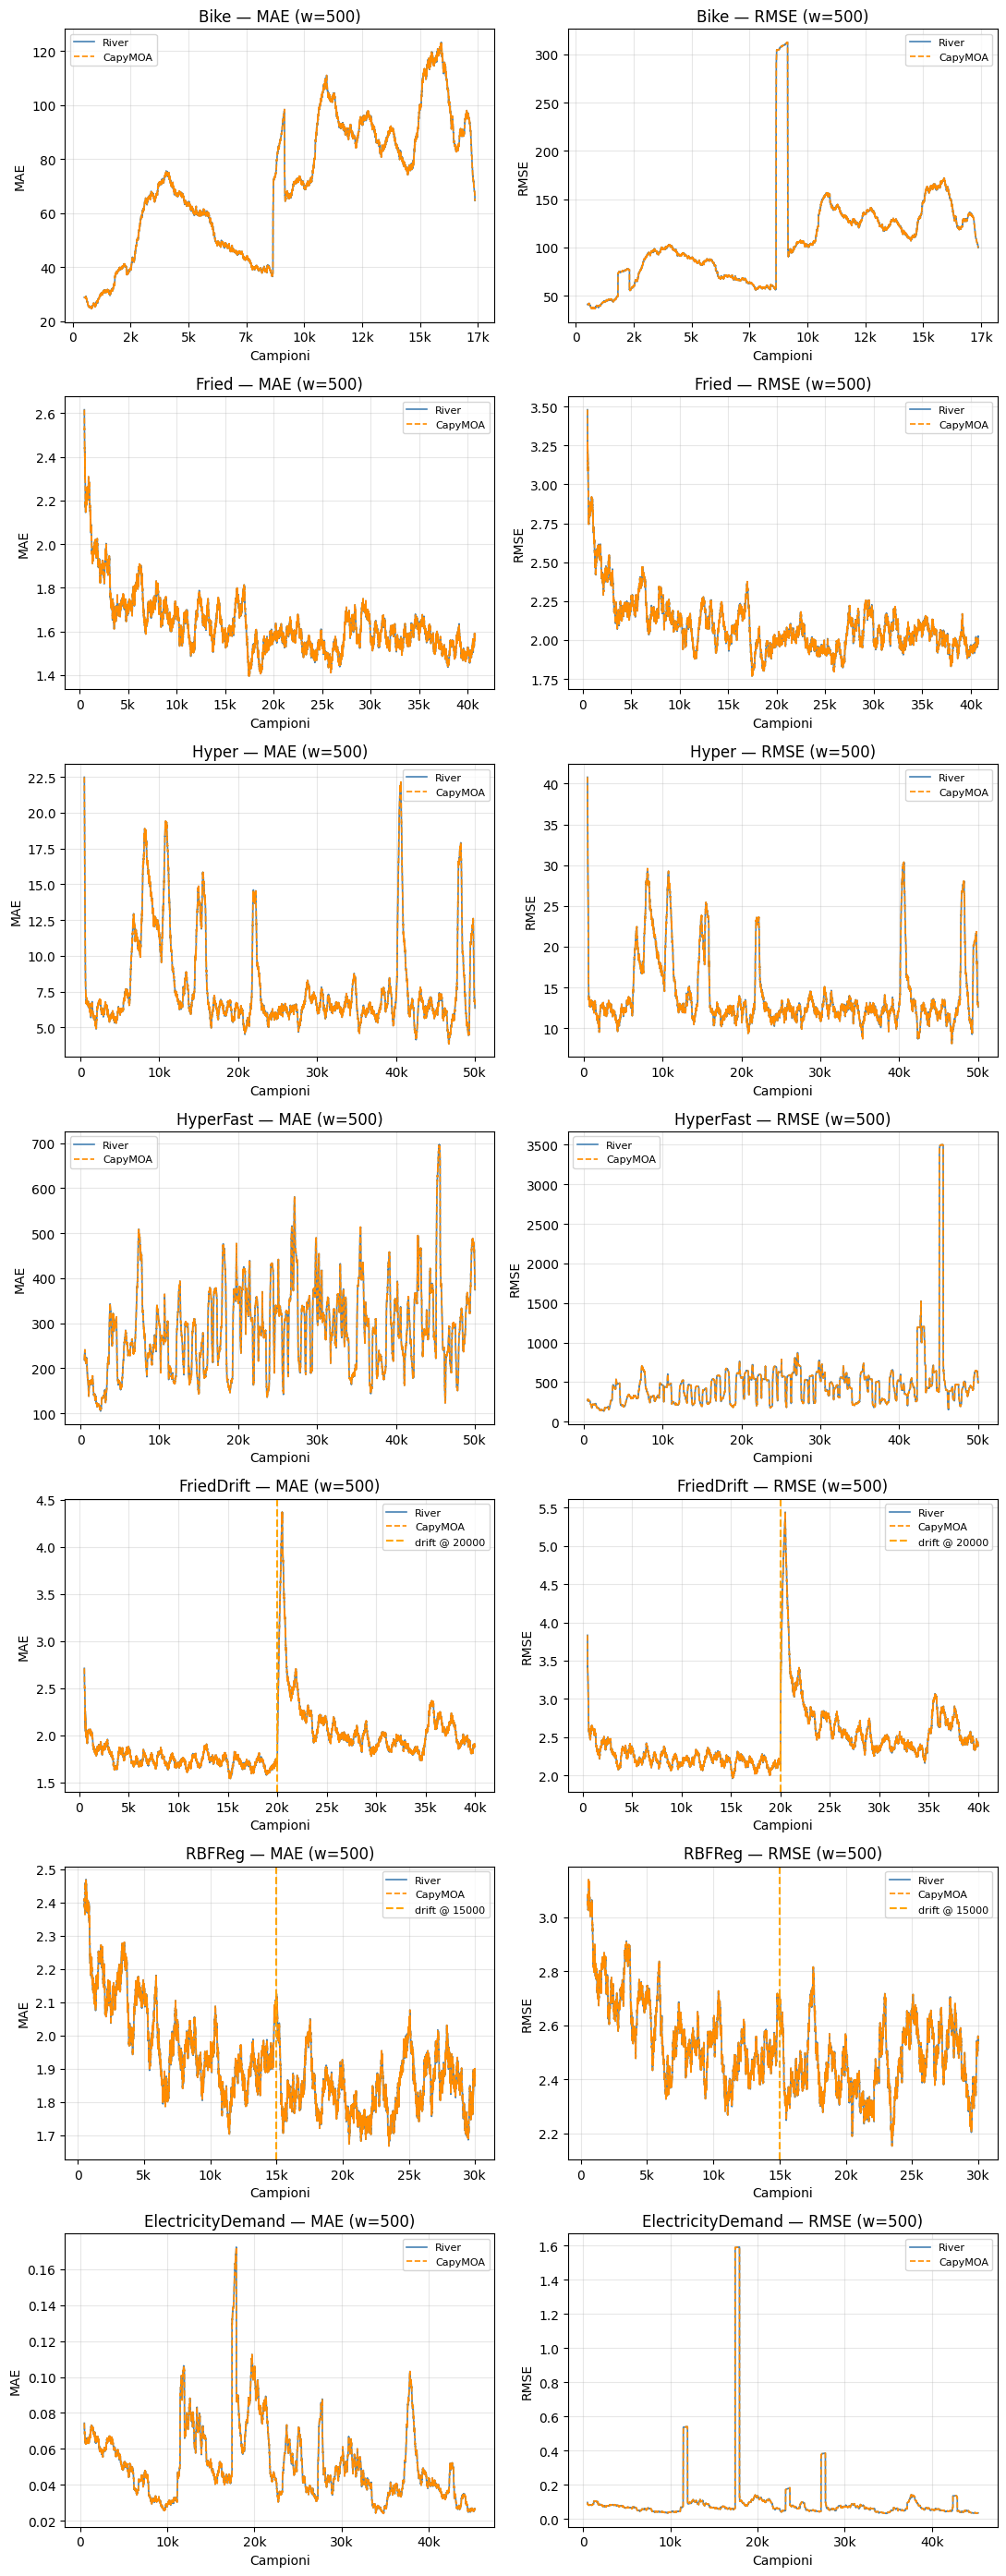

In [7]:
COL_R  = 'steelblue'
COL_C  = 'darkorange'
WINDOW = 500  # finestra sliding per MAE e RMSE

drift_points = {
    'FriedDrift': 20000,
    'RBFReg':     15000,
}

fig, axes = plt.subplots(len(results), 2, figsize=(11, 4 * len(results)))
if len(results) == 1:
    axes = axes[np.newaxis, :]

for row_idx, (name, d) in enumerate(results.items()):
    yt, rp, cp = d['y'], d['river'], d['capy']
    xs = np.arange(WINDOW - 1, len(yt))

    for col, (metric_fn, ylabel) in enumerate([
        (lambda yt, p: utils.win_mae(yt, p, WINDOW),  'MAE'),
        (lambda yt, p: utils.win_rmse(yt, p, WINDOW), 'RMSE'),
    ]):
        ax = axes[row_idx, col]
        ax.plot(xs, metric_fn(yt, rp), color=COL_R, lw=1.2, label='River')
        ax.plot(xs, metric_fn(yt, cp), color=COL_C, lw=1.2, ls='--', label='CapyMOA')
        if name in drift_points:
            ax.axvline(drift_points[name], color='orange', linestyle='--',
                       linewidth=1.5, label=f'drift @ {drift_points[name]}')
        ax.set(title=f'{name} — {ylabel} (w={WINDOW})', xlabel='Campioni', ylabel=ylabel)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f'{int(v/1000)}k' if v >= 1000 else str(int(v))))

plt.tight_layout()
plt.show()